In [114]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [115]:
fruit = pd.read_csv("cleaned_produce.csv")
df = fruit.pivot_table(index="date", columns="productname", values="averageretail")
print(df["Strawberries"])
chosen_fruit = df["Strawberries"]

date
1999-10-24    2.696667
1999-10-31    2.696667
1999-11-07    3.303333
1999-11-14    3.473333
1999-11-21    3.473333
                ...   
2019-04-21    2.820000
2019-04-28    2.710000
2019-05-05    2.483333
2019-05-12    2.600000
2019-05-19    2.253333
Name: Strawberries, Length: 1019, dtype: float64


In [116]:
df.index = pd.to_datetime(df.index)
df.index.month

Index([10, 10, 11, 11, 11, 11, 12, 12, 12, 12,
       ...
        3,  3,  3,  4,  4,  4,  4,  5,  5,  5],
      dtype='int32', name='date', length=1019)

In [117]:
def detrending(fruit_series):
    # generate dataframe
    new_df = pd.DataFrame()
    new_df["fruit"] = fruit_series
    new_df.index = pd.to_datetime(new_df.index)   # conver the index to datetime for convenience
    new_df = new_df.sort_index()

    # estimate trend using centered moving average (2x12)
    new_df["trend_estimate"] = new_df["fruit"].rolling(12).mean().rolling(2).mean().shift(-6)

    # detrend and get seasonality
    new_df["detrended"] = new_df["fruit"] - new_df["trend_estimate"]
    seasonality = new_df.groupby(new_df.index.month)["detrended"].mean()
    adjusted = seasonality - seasonality.mean()
    new_df["seasonal_estimate"] = new_df.index.month.map(adjusted)

    # get residuals
    new_df["residuals"] = new_df["fruit"] - new_df["trend_estimate"]

    return new_df


In [118]:
ddf = detrending(chosen_fruit)
ddf

,fruit,trend_estimate,detrended,seasonal_estimate,residuals
date,,,,,
1999-10-24,2.696667,NaN,NaN,-0.128837,NaN
1999-10-31,2.696667,NaN,NaN,-0.128837,NaN
1999-11-07,3.303333,NaN,NaN,0.139052,NaN
1999-11-14,3.473333,NaN,NaN,0.139052,NaN
1999-11-21,3.473333,NaN,NaN,0.139052,NaN
...,...,...,...,...,...
2019-04-21,2.820000,NaN,NaN,-0.010175,NaN
2019-04-28,2.710000,NaN,NaN,-0.010175,NaN
2019-05-05,2.483333,NaN,NaN,-0.047155,NaN


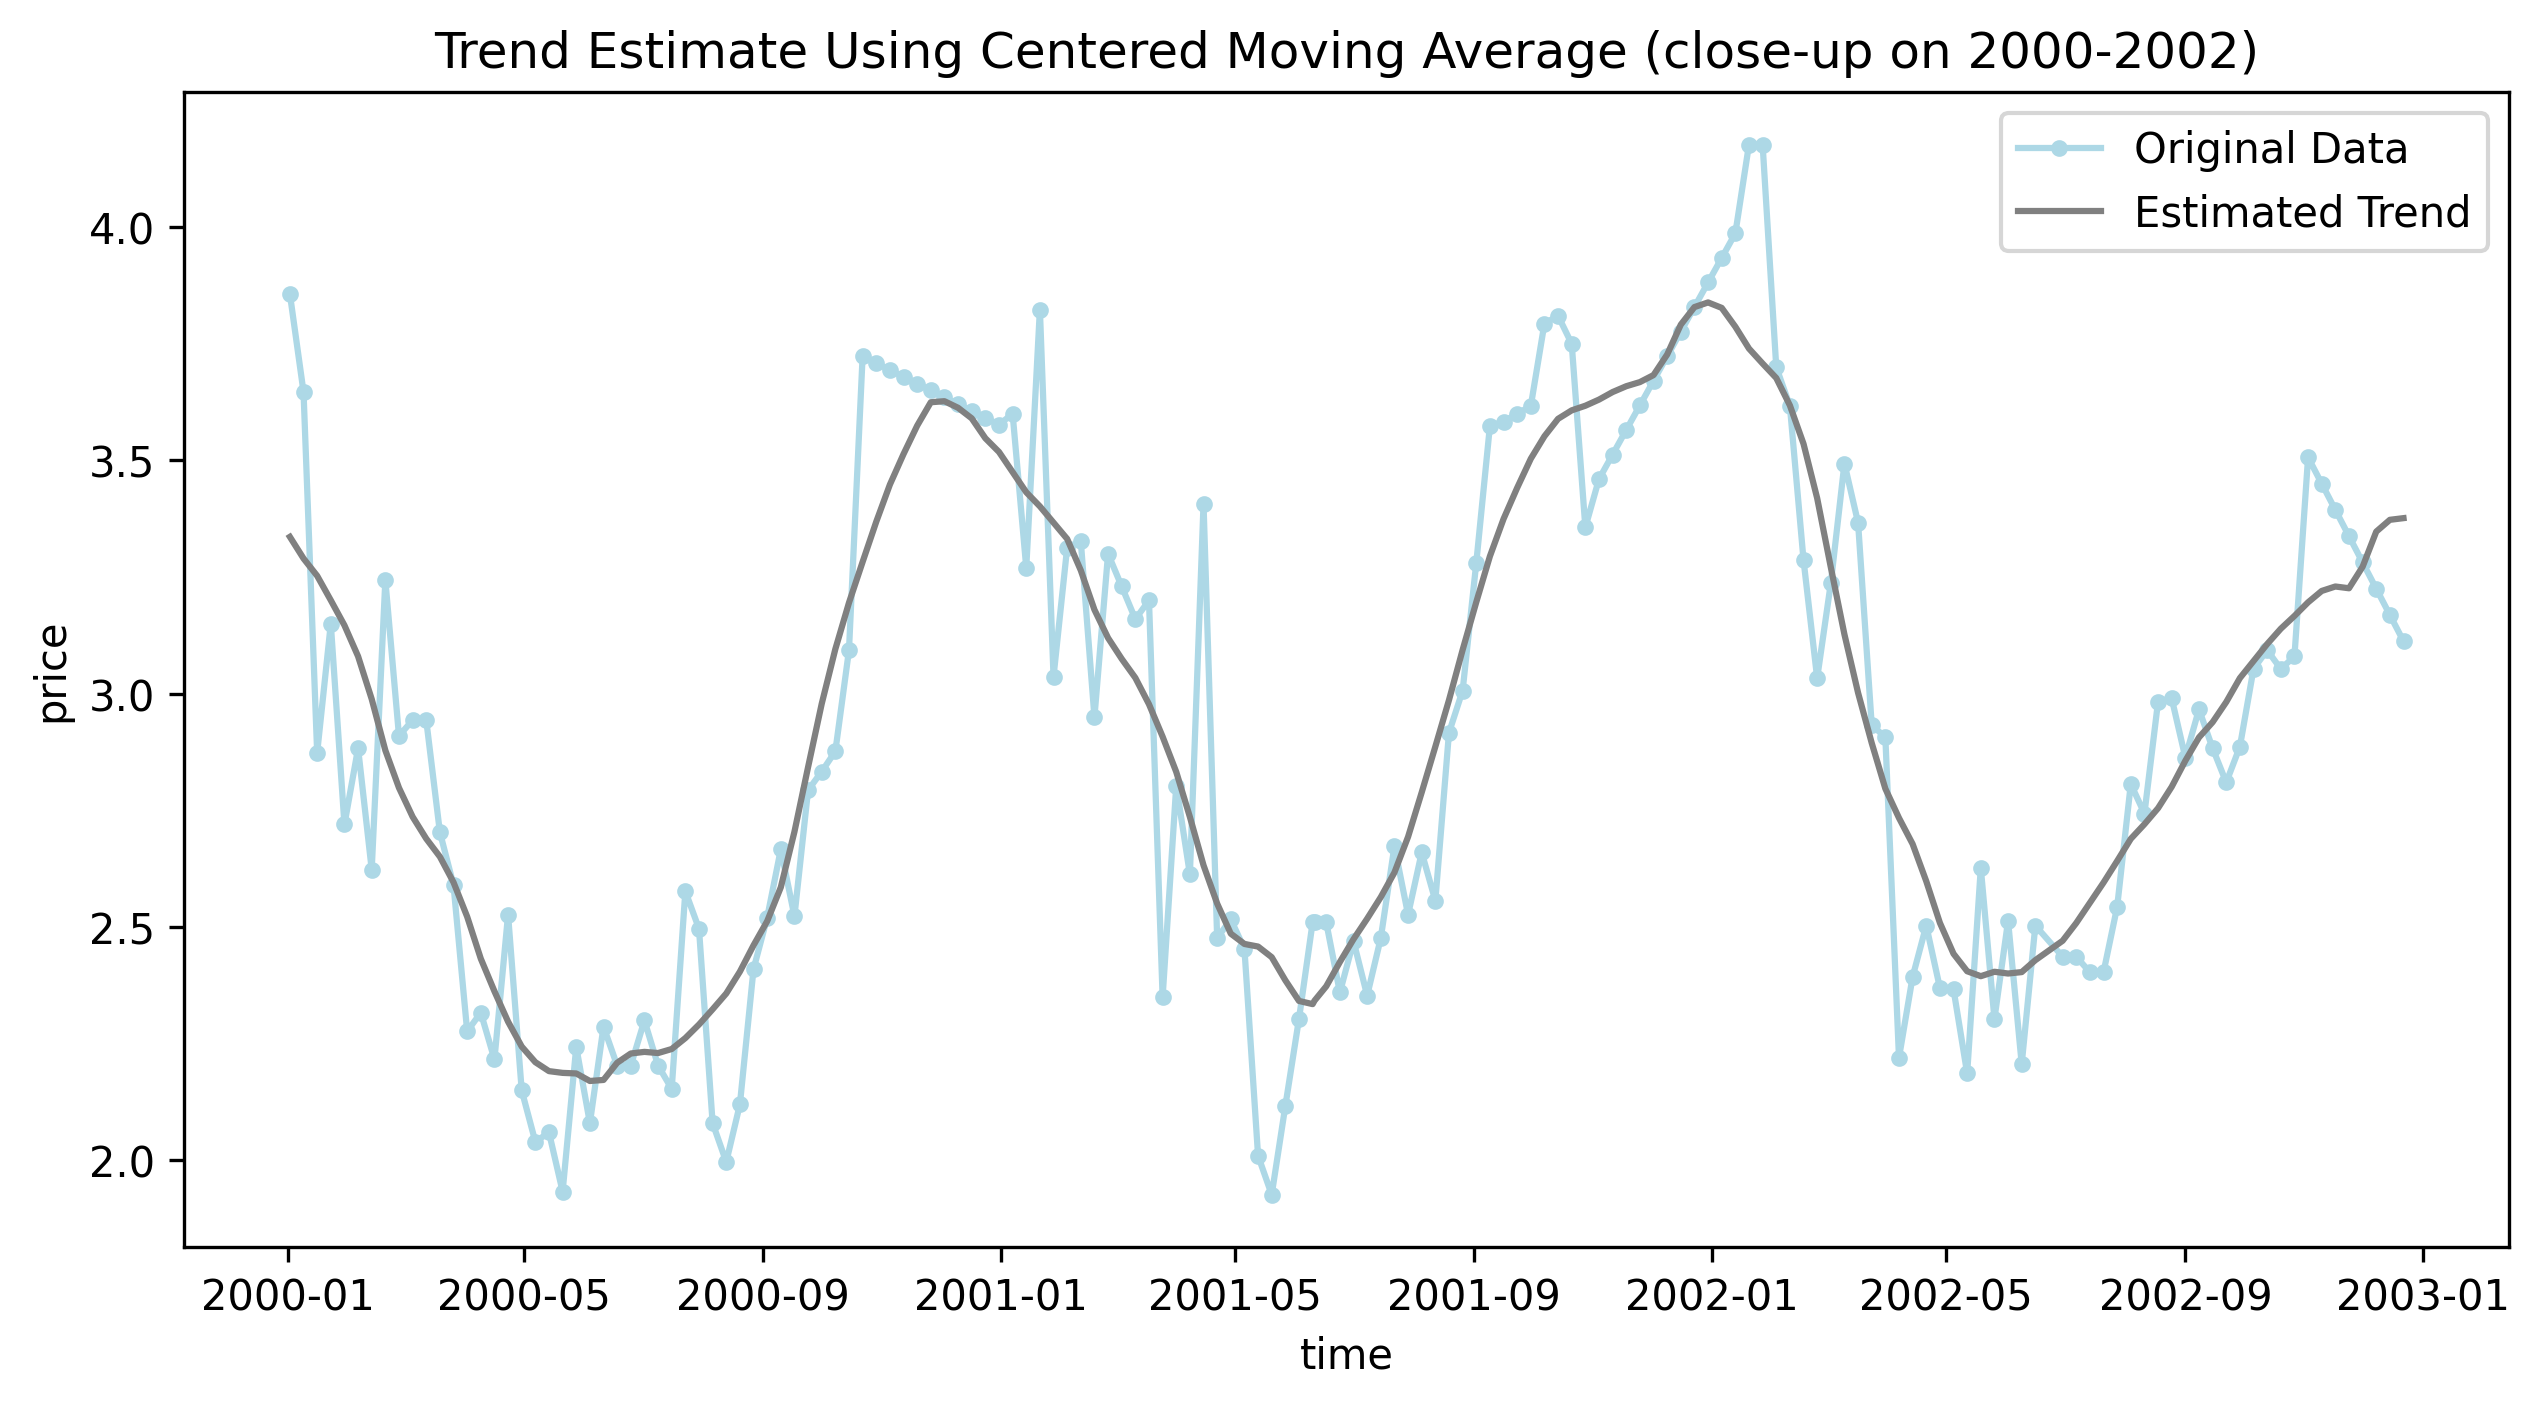

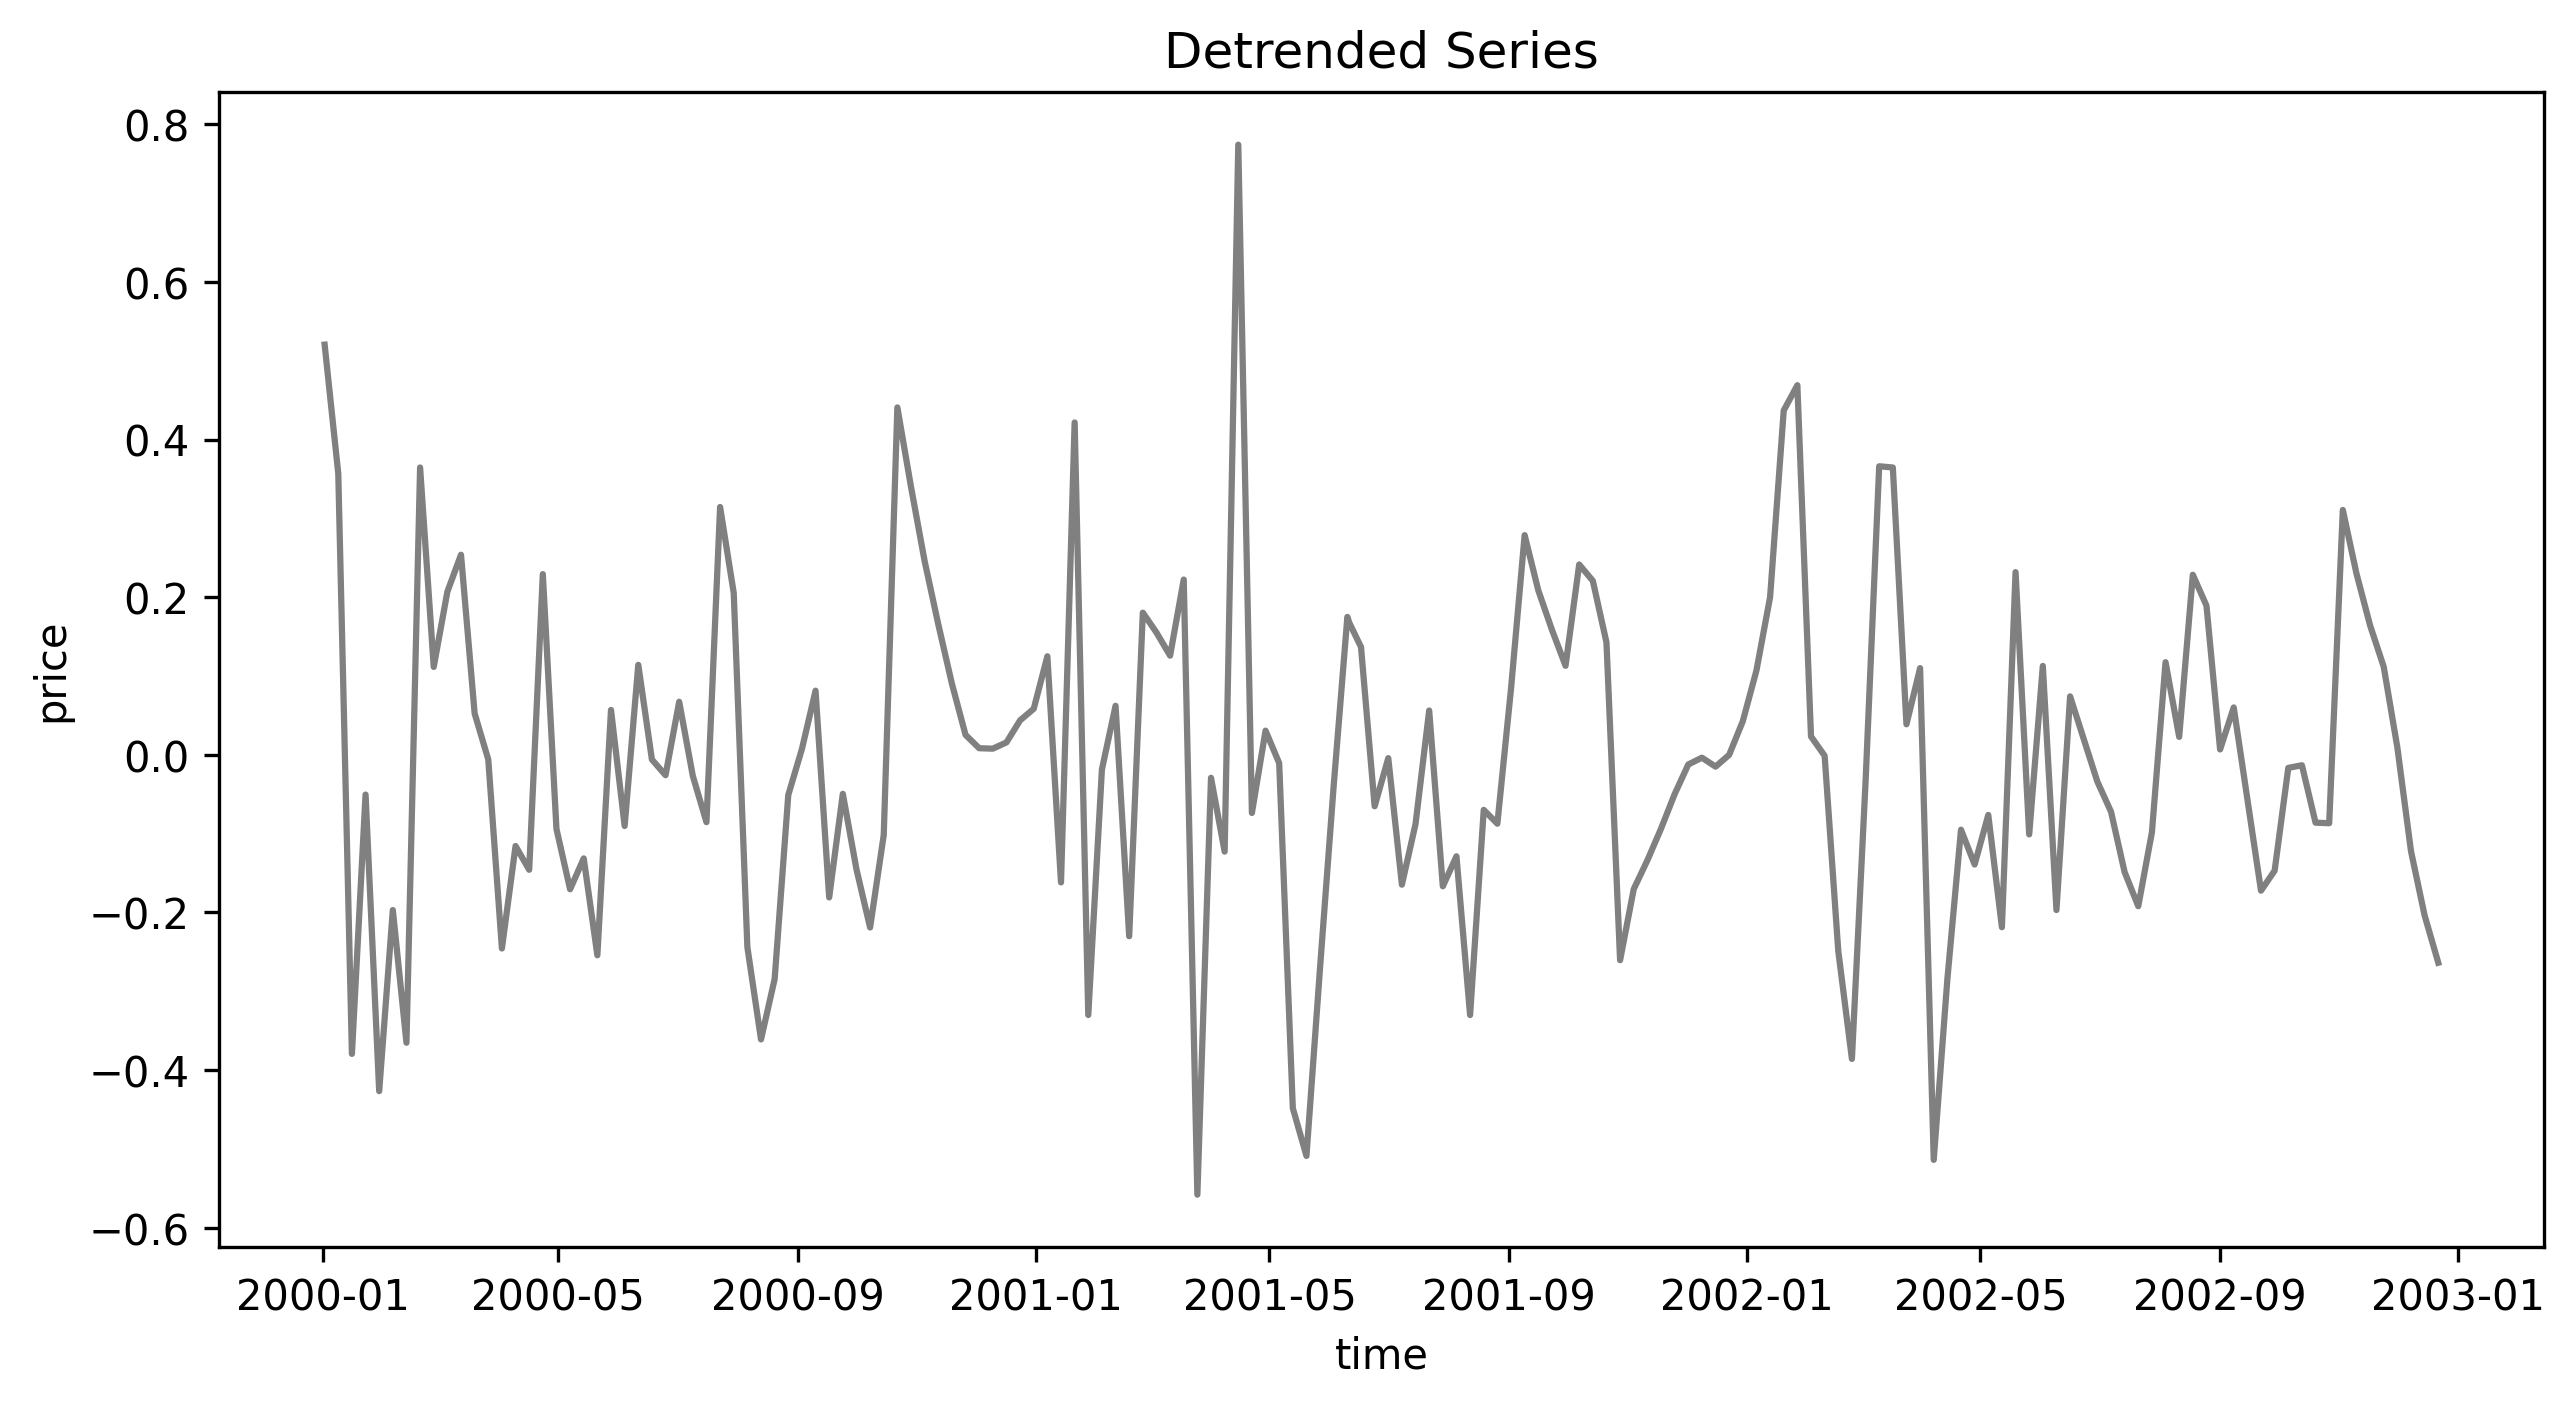

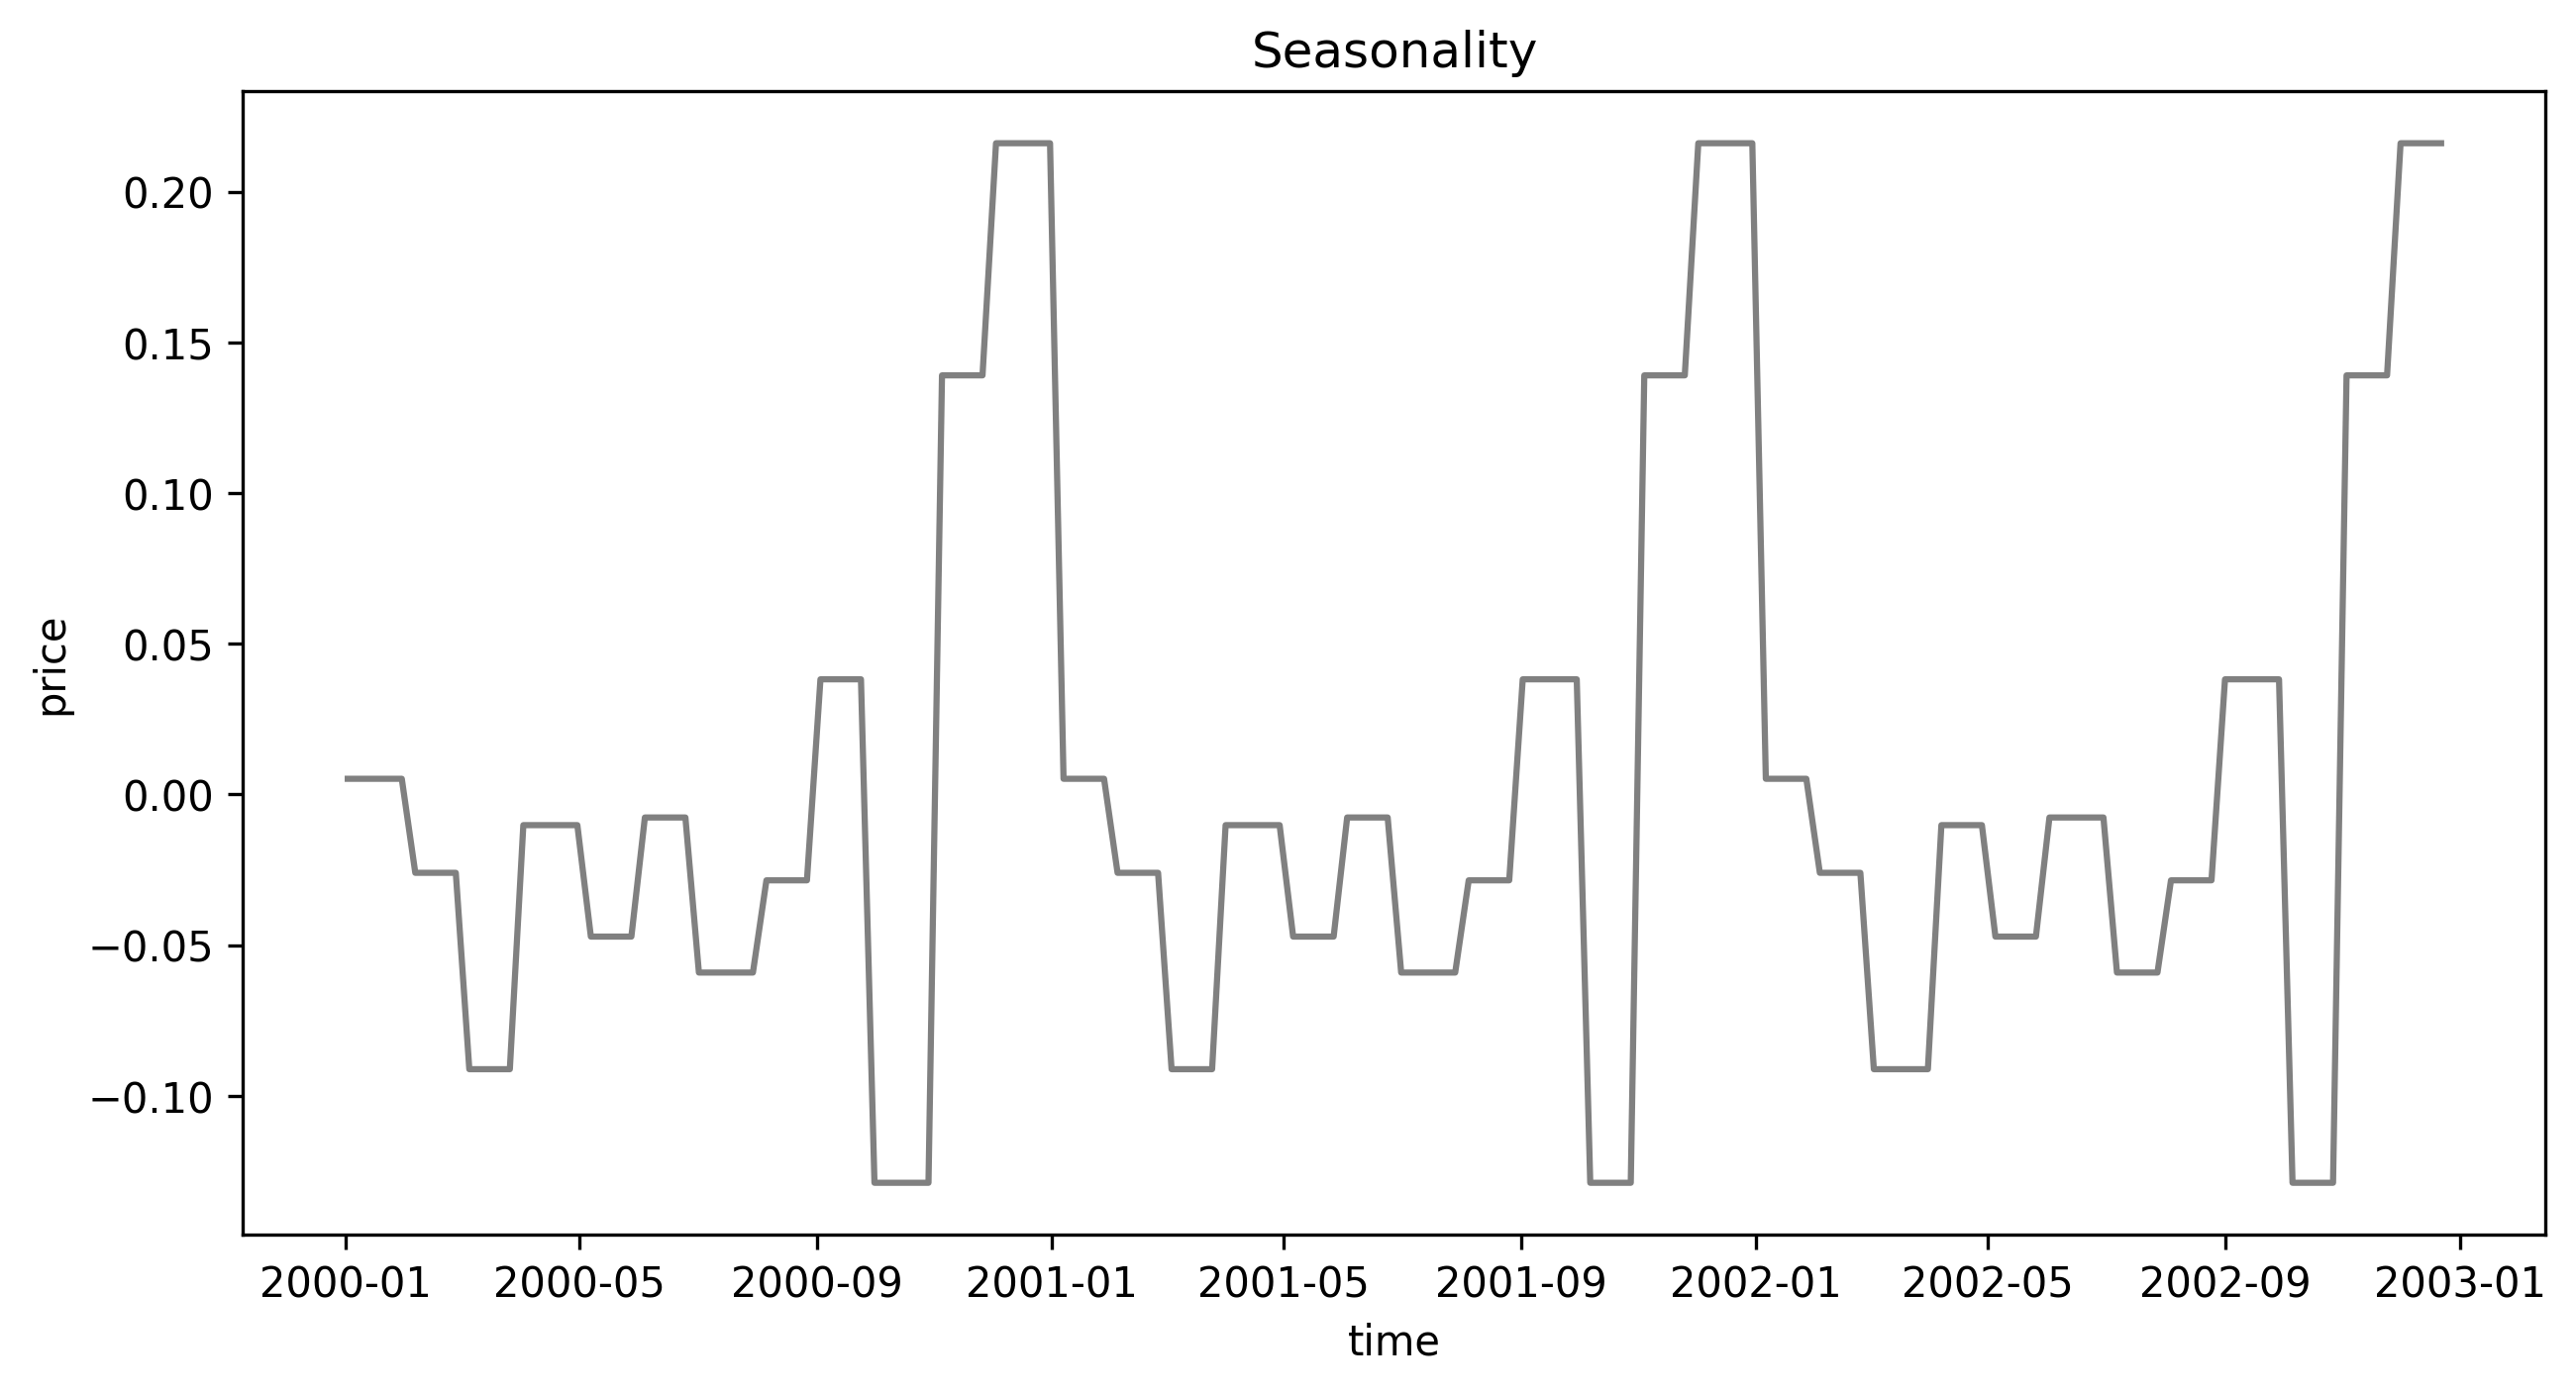

In [119]:
# plot original vs trend
plt.figure(figsize=(10, 5), dpi=300)
plt.plot(ddf.index[10:166], ddf['fruit'][10:166], marker='.', c='lightblue', label="Original Data")
plt.plot(ddf.index[10:166], ddf["trend_estimate"][10:166], color="gray", label="Estimated Trend")
plt.title("Trend Estimate Using Centered Moving Average (close-up on 2000-2002)")
plt.legend()
plt.xlabel("time")
plt.ylabel("price")
plt.show()

# plot detrended
plt.figure(figsize=(10, 5), dpi=300)
# plt.plot(ddf.index[10:166], ddf['fruit'][10:166] - ddf['fruit'].mean(), marker='.', c='lightblue', label="Original Data")
plt.plot(ddf.index[10:166], ddf['detrended'][10:166], color='gray', label='detrended')
plt.title("Detrended Series")
# plt.legend()
plt.xlabel("time")
plt.ylabel("price")
plt.show()

# plot seasonal component
plt.figure(figsize=(10, 5), dpi=300)
plt.plot(ddf.index[10:166], ddf['seasonal_estimate'][10:166], color='gray', label='seasonal estimate')
plt.title("Seasonality")
plt.xlabel("time")
plt.ylabel("price")
plt.show()